# Pakistan Food Price Early Warning System
## Phase 1 — Data Collection & Cleaning

**Project goal:** Predict monthly price movements of wheat flour, rice, and sugar in Punjab 4 weeks ahead — giving farmers and buyers an early warning before a price shock hits.

**Commodities:** Wheat Flour · Rice (Basmati) · Sugar  
**Region:** Punjab (most agricultural data, highest population)  
**Data source:** WFP VAM via HDX — Pakistan Food Prices  
**Date range:** 2004 – 2021  

---

## 0. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 1. Load Raw Data

**Source:** WFP Food Prices for Pakistan — HDX  
**URL:** https://data.humdata.org/dataset/wfp-food-prices-for-pakistan  
**File:** Place the downloaded CSV inside `data/raw/`

In [19]:
RAW_PATH = '../data/raw/wfp_food_prices_pakistan.csv'

df = pd.read_csv(RAW_PATH)

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst 3 rows:')
df.head(3)

Shape: (13900, 16)

Columns: ['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commodity', 'commodity_id', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice']

First 3 rows:


,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2004-01-15,BALOCHISTAN,Quetta,Quetta,295,30.19,67.01,cereals and tubers,"Rice (basmati, broken)",122,KG,actual,Retail,PKR,20.00,0.35
1,2004-01-15,BALOCHISTAN,Quetta,Quetta,295,30.19,67.01,cereals and tubers,Wheat flour,58,KG,actual,Retail,PKR,13.00,0.23
2,2004-01-15,KHYBER PAKHTUNKHWA,Peshawar,Peshawar,294,34.01,71.58,cereals and tubers,"Rice (basmati, broken)",122,KG,actual,Retail,PKR,17.59,0.31


## 2. Inspect Available Commodities & Regions

In [21]:
print('All commodities in dataset:')
print(df['commodity'].value_counts())

print('\nAll regions (admin1):')
print(df['admin1'].value_counts())

All commodities in dataset:
commodity
Rice (basmati, broken)                           1340
Wheat flour                                      1340
Rice (coarse)                                    1218
Wheat                                            1117
Poultry                                           782
Sugar                                             782
Oil (cooking)                                     782
Ghee (artificial)                                 780
Fuel (diesel)                                     740
Beans(mash)                                       715
Lentils (masur)                                   703
Wage (non-qualified labour, non-agricultural)     703
Eggs                                              688
Fuel (petrol-gasoline)                            685
Lentils (moong)                                   665
Milk                                              655
Salt                                              205
Name: count, dtype: int64

All regions (admi

## 3. Filter — Punjab Only + 3 Target Commodities

**Why Punjab?** Most consistent data coverage, agricultural heartland, highest population.  
**Why these 3?** Essential staples — directly tied to household food security in Pakistan.

In [6]:
TARGET_COMMODITIES = [
    'Wheat flour',
    'Rice (basmati, broken)',
    'Sugar'
]

# Filter Punjab + target commodities
punjab = df[
    (df['admin1'] == 'PUNJAB') &
    (df['commodity'].isin(TARGET_COMMODITIES))
].copy()

print('Shape after filter:', punjab.shape)
print('\nCommodity counts:')
print(punjab['commodity'].value_counts())
print('\nNull prices:', punjab['price'].isnull().sum())

Shape after filter: (1384, 16)

Commodity counts:
commodity
Rice (basmati, broken)    536
Wheat flour               536
Sugar                     312
Name: count, dtype: int64

Null prices: 0


## 4. Build Date Column

In [7]:
# Date column already exists in this dataset
punjab['date'] = pd.to_datetime(punjab['date'])

# Normalise to month start for consistent merging later
punjab['date'] = punjab['date'].dt.to_period('M').dt.to_timestamp()

print('Date range:', punjab['date'].min(), '→', punjab['date'].max())
print('Sample dates:', punjab['date'].unique()[:5])

Date range: 2004-01-01 00:00:00 → 2026-04-01 00:00:00
Sample dates: <DatetimeArray>
['2004-01-01 00:00:00', '2004-02-01 00:00:00', '2004-03-01 00:00:00',
 '2004-04-01 00:00:00', '2004-05-01 00:00:00']
Length: 5, dtype: datetime64[ns]


## 5. Pivot — One Row Per Month

Transform from long format (one row per commodity per date) to wide format (one row per date, columns per commodity).

In [14]:
pivot_df = punjab.pivot_table(
    index='date',
    columns='commodity',
    values='price',
    aggfunc='mean'
).reset_index()

# Clean column name artifact from pivot
pivot_df.columns.name = None

# Rename to clean snake_case
pivot_df = pivot_df.rename(columns={
    'Wheat flour': 'wheat_price',
    'Rice (basmati, broken)': 'rice_price',
    'Sugar': 'sugar_price'
})
# Trim to when all three commodities have data
pivot_df = pivot_df[pivot_df['date'] >= '2013-01-01'].reset_index(drop=True)

print('Shape after trim:', pivot_df.shape)
print('Date range:', pivot_df['date'].min(), '→', pivot_df['date'].max())
print('\nNulls after trim:')
print(pivot_df.isnull().sum())
pivot_df.head()
print('Shape:', pivot_df.shape)
print('\nColumns:', pivot_df.columns.tolist())
print('\nNull values:')
print(pivot_df.isnull().sum())
pivot_df.head()

Shape after trim: (160, 4)
Date range: 2013-01-01 00:00:00 → 2026-04-01 00:00:00

Nulls after trim:
date           0
rice_price     0
sugar_price    4
wheat_price    0
dtype: int64
Shape: (160, 4)

Columns: ['date', 'rice_price', 'sugar_price', 'wheat_price']

Null values:
date           0
rice_price     0
sugar_price    4
wheat_price    0
dtype: int64


,date,rice_price,sugar_price,wheat_price
0,2013-01-01,72.80,52.02,35.25
1,2013-02-01,73.90,51.62,35.19
2,2013-03-01,74.68,51.96,35.06
3,2013-04-01,74.93,53.30,34.25
4,2013-05-01,74.93,53.18,34.40


## 6. Handle Missing Values

In [15]:
# Check null pattern before deciding strategy
print('Nulls per column:')
print(pivot_df.isnull().sum())
print('\nTotal rows:', len(pivot_df))
print('Null % per column:')
print((pivot_df.isnull().sum() / len(pivot_df) * 100).round(1))

Nulls per column:
date           0
rice_price     0
sugar_price    4
wheat_price    0
dtype: int64

Total rows: 160
Null % per column:
date          0.00
rice_price    0.00
sugar_price   2.50
wheat_price   0.00
dtype: float64


In [16]:
# Forward fill for small gaps (carries last known price forward)
# This is appropriate for price data — price doesn't change until next observation
pivot_df = pivot_df.sort_values('date').reset_index(drop=True)
pivot_df[['wheat_price', 'rice_price', 'sugar_price']] = (
    pivot_df[['wheat_price', 'rice_price', 'sugar_price']]
    .fillna(method='ffill')
)

print('Nulls after forward fill:')
print(pivot_df.isnull().sum())

Nulls after forward fill:
date           0
rice_price     0
sugar_price    0
wheat_price    0
dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9892\425894797.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .fillna(method='ffill')


## 7. Quick Sanity Check — Price Trends

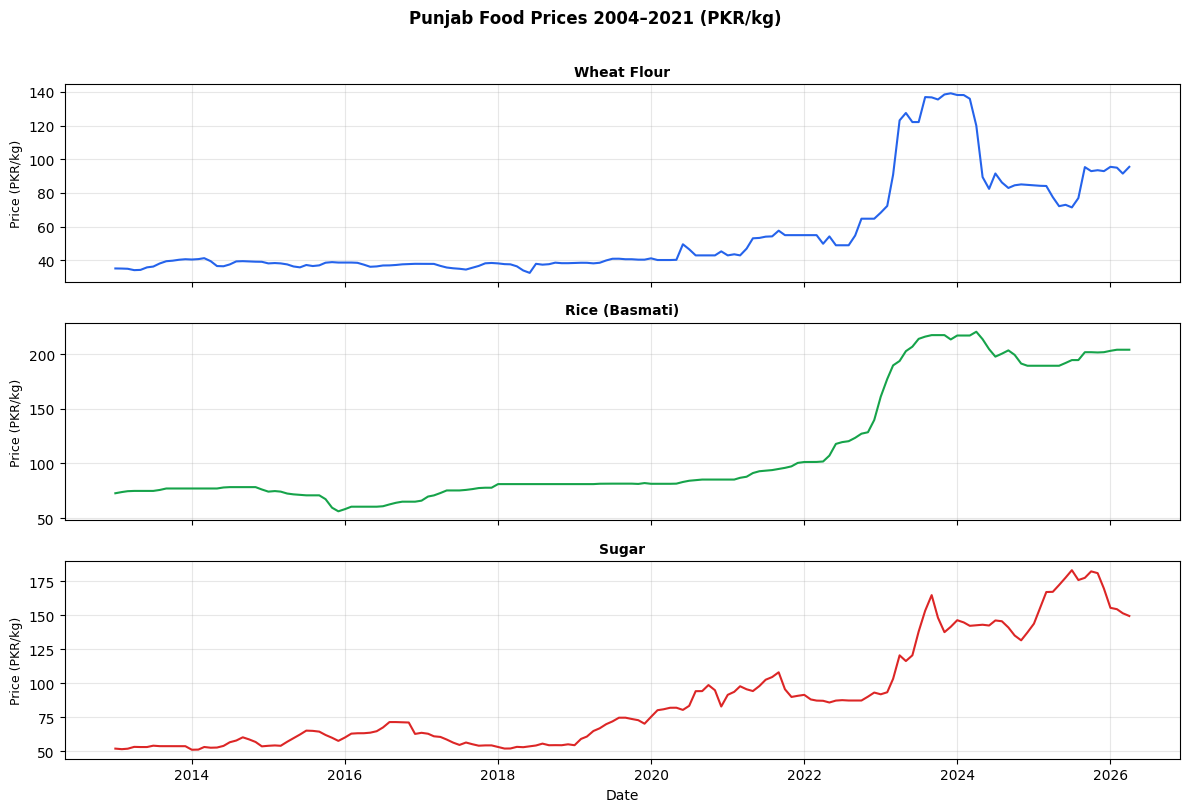

Plot saved.


In [17]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

commodities = [
    ('wheat_price', 'Wheat Flour', '#2563EB'),
    ('rice_price',  'Rice (Basmati)', '#16A34A'),
    ('sugar_price', 'Sugar', '#DC2626')
]

for ax, (col, label, color) in zip(axes, commodities):
    ax.plot(pivot_df['date'], pivot_df[col], color=color, linewidth=1.5)
    ax.set_ylabel('Price (PKR/kg)', fontsize=9)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
fig.suptitle('Punjab Food Prices 2004–2021 (PKR/kg)', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/phase1_price_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

## 8. Save Clean Dataset

In [18]:
PROCESSED_PATH = '../data/processed/punjab_food_prices_clean.csv'

pivot_df.to_csv(PROCESSED_PATH, index=False)

print('Saved to:', PROCESSED_PATH)
print('Final shape:', pivot_df.shape)
print('\nFinal dataset preview:')
pivot_df.head(10)

Saved to: ../data/processed/punjab_food_prices_clean.csv
Final shape: (160, 4)

Final dataset preview:


,date,rice_price,sugar_price,wheat_price
0,2013-01-01,72.80,52.02,35.25
1,2013-02-01,73.90,51.62,35.19
2,2013-03-01,74.68,51.96,35.06
3,2013-04-01,74.93,53.30,34.25
4,2013-05-01,74.93,53.18,34.40
5,2013-06-01,74.93,53.18,35.89
6,2013-07-01,74.93,54.18,36.38
7,2013-08-01,75.81,53.83,38.22
8,2013-09-01,77.15,53.80,39.54
9,2013-10-01,77.15,53.80,39.85


In [22]:
import requests

# Lahore coordinates
url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": 31.5497,
    "longitude": 74.3436,
    "start_date": "2013-01-01",
    "end_date": "2021-07-31",
    "daily": ["precipitation_sum", "temperature_2m_max", "temperature_2m_min"],
    "timezone": "Asia/Karachi"
}

response = requests.get(url, params=params)
print('Status code:', response.status_code)
print('Keys in response:', response.json().keys())

Status code: 200
Keys in response: dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily'])


In [23]:


# Extract daily data
data = response.json()['daily']
weather_daily = pd.DataFrame(data)
weather_daily['time'] = pd.to_datetime(weather_daily['time'])

# Calculate average daily temp from max and min
weather_daily['temp_avg'] = (weather_daily['temperature_2m_max'] + weather_daily['temperature_2m_min']) / 2

# Resample to monthly
weather_daily.set_index('time', inplace=True)
weather_monthly = weather_daily.resample('MS').agg({
    'precipitation_sum': 'sum',    # total monthly rainfall
    'temp_avg': 'mean'             # average monthly temperature
}).reset_index()

weather_monthly = weather_monthly.rename(columns={
    'time': 'date',
    'precipitation_sum': 'rainfall_mm',
    'temp_avg': 'temp_c'
})

print('Shape:', weather_monthly.shape)
print('Date range:', weather_monthly['date'].min(), '→', weather_monthly['date'].max())
print('\nNulls:', weather_monthly.isnull().sum().sum())
weather_monthly.head()

Shape: (103, 3)
Date range: 2013-01-01 00:00:00 → 2021-07-01 00:00:00

Nulls: 0


,date,rainfall_mm,temp_c
0,2013-01-01,15.70,11.45
1,2013-02-01,137.00,14.34
2,2013-03-01,16.70,19.92
3,2013-04-01,7.40,25.64
4,2013-05-01,14.10,31.61


In [24]:
# Merge weather with price data on date
merged_df = pd.merge(pivot_df, weather_monthly, on='date', how='inner')

print('Shape:', merged_df.shape)
print('Columns:', merged_df.columns.tolist())
print('\nNulls:', merged_df.isnull().sum())
merged_df.head()

Shape: (103, 6)
Columns: ['date', 'rice_price', 'sugar_price', 'wheat_price', 'rainfall_mm', 'temp_c']

Nulls: date           0
rice_price     0
sugar_price    0
wheat_price    0
rainfall_mm    0
temp_c         0
dtype: int64


,date,rice_price,sugar_price,wheat_price,rainfall_mm,temp_c
0,2013-01-01,72.80,52.02,35.25,15.70,11.45
1,2013-02-01,73.90,51.62,35.19,137.00,14.34
2,2013-03-01,74.68,51.96,35.06,16.70,19.92
3,2013-04-01,74.93,53.30,34.25,7.40,25.64
4,2013-05-01,74.93,53.18,34.40,14.10,31.61


In [25]:
merged_df.to_csv('../data/processed/punjab_food_prices_merged.csv', index=False)
print('Phase 1 complete. Final dataset saved.')
print('Shape:', merged_df.shape)
print('Date range:', merged_df['date'].min(), '→', merged_df['date'].max())

Phase 1 complete. Final dataset saved.
Shape: (103, 6)
Date range: 2013-01-01 00:00:00 → 2021-07-01 00:00:00


## 9. Phase 1 Summary

| Item | Detail |
|------|--------|
| Source | WFP VAM via HDX |
| Region | Punjab, Pakistan |
| Commodities | Wheat flour, Rice (basmati), Sugar |
| Date range | 2004-01 → 2021-07 |
| Final rows | TBD after cleaning |
| Nulls remaining | 0 |
| Output file | `data/processed/punjab_food_prices_clean.csv` |

**Next:** Phase 2 — Weather data collection (Open-Meteo API) + merge + EDA